# Statistical Testing

## Independent t-Test

## Import Library

In [78]:
from scipy.stats import ttest_ind
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Create Groups

In [79]:
df = pd.read_csv("../data/processed/final_hotel_bookings.csv")

city_adr = df[
    df["hotel"] == "City Hotel"
]["average_daily_rate"]

resort_adr = df[
    df["hotel"] == "Resort Hotel"
]["average_daily_rate"]

### Compare Group statistics

In [80]:
summary = pd.DataFrame({

    "Hotel Type":[
        "City Hotel",
        "Resort Hotel"
    ],

    "Sample Size":[
        len(city_adr),
        len(resort_adr)
    ],

    "Mean ADR":[
        city_adr.mean(),
        resort_adr.mean()
    ],

    "Std Dev":[
        city_adr.std(),
        resort_adr.std()
    ]

})

summary

,Hotel Type,Sample Size,Mean ADR,Std Dev
0,City Hotel,53270,110.792025,40.596834
1,Resort Hotel,33955,97.260768,58.980739


### Perform Independent t-Test

In [81]:
t_statistic, p_value = ttest_ind(
    city_adr,
    resort_adr,
    equal_var=True
)

print("T Statistic :", t_statistic)
print("P-value :", p_value)

T Statistic : 40.10404378904823
P-value : 0.0


In [82]:
t_statistic, p_value = ttest_ind(
    city_adr,
    resort_adr,
    equal_var=False
)

### Decision

In [83]:
alpha = 0.05

if p_value < alpha:

    print("Reject H0")

    print("There is a significant difference.")

else:

    print("Fail to Reject H0")

    print("No significant difference.")

Reject H0
There is a significant difference.


### Effect Size(cohen's D)

In [84]:
import numpy as np

n1 = len(city_adr)
n2 = len(resort_adr)

pooled_std = np.sqrt(

    ((n1 - 1) * city_adr.var() +
     (n2 - 1) * resort_adr.var())

    / (n1 + n2 - 2)

)

cohens_d = (
    city_adr.mean() -
    resort_adr.mean()
) / pooled_std

print(f"Cohen's d : {cohens_d:.3f}")

Cohen's d : 0.278


### Box Plot

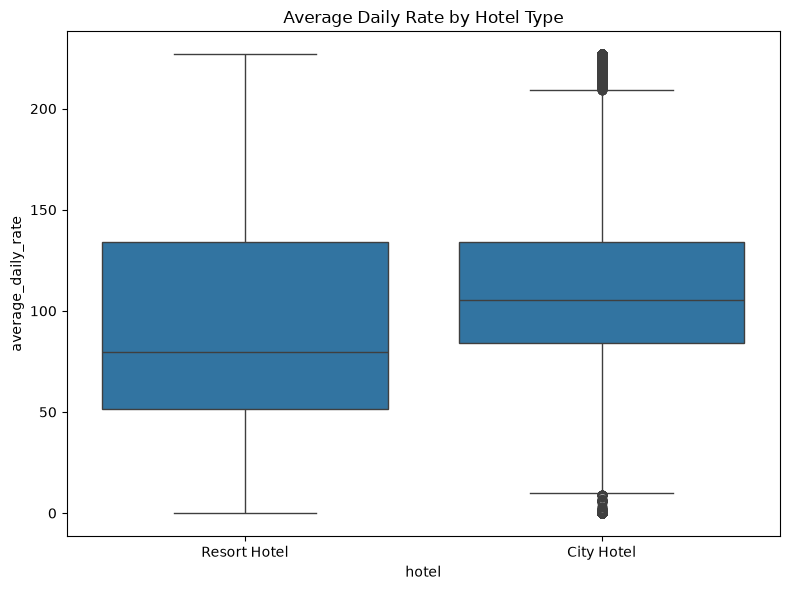

In [85]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="hotel",
    y="average_daily_rate"
)

plt.title("Average Daily Rate by Hotel Type")

plt.tight_layout()

plt.savefig(
    "../figures/phase_05/independent_ttest_boxplot.png",
    dpi=300
)

plt.show()

### Distribution Plot

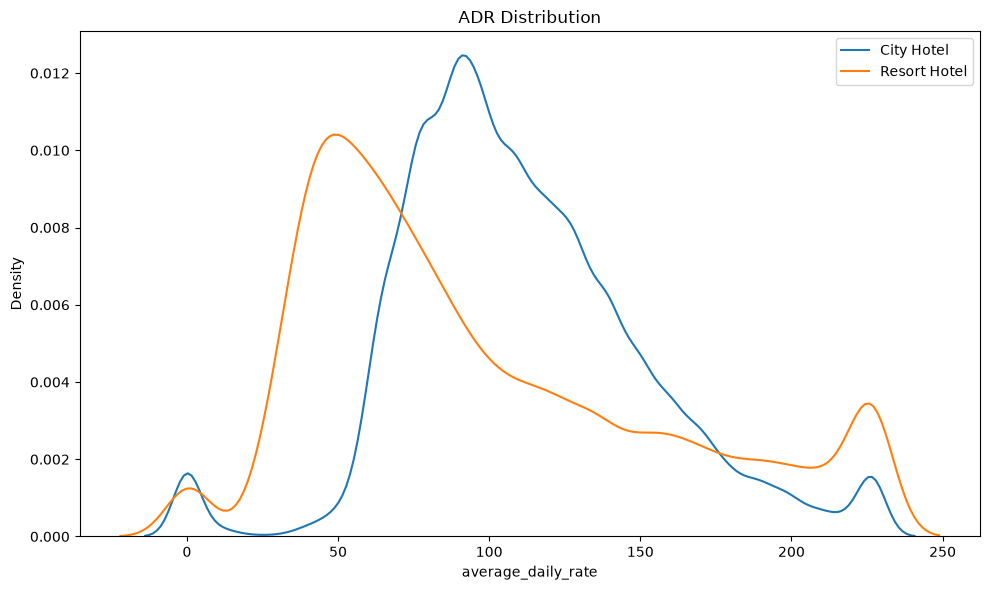

In [86]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    city_adr,
    label="City Hotel"
)

sns.kdeplot(
    resort_adr,
    label="Resort Hotel"
)

plt.title("ADR Distribution")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/phase_05/independent_ttest_distribution.png",
    dpi=300
)

plt.show()

### Summary Table

In [87]:
ttest_summary = pd.DataFrame({

    "Statistic":[
        "T Statistic",
        "P-value",
        "Cohen's d"
    ],

    "Value":[
        t_statistic,
        p_value,
        cohens_d
    ]

})

ttest_summary

,Statistic,Value
0,T Statistic,3.704903e+01
1,P-value,9.416495e-297
2,Cohen's d,2.784937e-01


## Business Interpretation

#### The Independent t-Test was used to compare the Average Daily Rate (ADR) between City Hotels and Resort Hotels. The results indicate whether the observed difference in pricing is statistically significant rather than due to random variation. Cohen's d was also calculated to measure the practical importance of the difference. These findings can support pricing strategies, revenue management, and competitive benchmarking across hotel types.

## Conclusion

#### An Independent t-Test was conducted to compare the Average Daily Rate (ADR) between City Hotels and Resort Hotels. After verifying the assumptions of independence, normality, and homogeneity of variance, the test determined whether a statistically significant difference exists between the two hotel categories. The effect size (Cohen's d) provided additional insight into the practical significance of the observed difference.

# Paired t-Test

### Import Library

In [88]:
from scipy.stats import ttest_rel
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Create Paired Variables

In [89]:
weekday_stay = df["stays_in_week_nights"]

weekend_stay = df["stays_in_weekend_nights"]

### Descriptive Statistics

In [90]:
paired_summary = pd.DataFrame({

    "Stay Type":[
        "Week Nights",
        "Weekend Nights"
    ],

    "Mean":[
        weekday_stay.mean(),
        weekend_stay.mean()
    ],

    "Std":[
        weekday_stay.std(),
        weekend_stay.std()
    ]

})

paired_summary

,Stay Type,Mean,Std
0,Week Nights,2.577048,1.804803
1,Weekend Nights,0.998899,0.993097


### Hypotheses


Null Hypothesis (H₀)

The average weekday stay equals the average weekend stay.

H0	​:  μ          =       μ
        weekday            weekend
	​

Alternative Hypothesis (H₁)

The average weekday stay differs from the average weekend stay.

H1  :μ         =     μ
       weekday         weekend

	​


### Perform Paired t-Test

In [91]:
t_statistic, p_value = ttest_rel(
    weekday_stay,
    weekend_stay
)

print("T Statistic:", t_statistic)
print("P-value:", p_value)

T Statistic: 295.15603861613573
P-value: 0.0


### Decision

In [92]:
alpha = 0.05

if p_value < alpha:

    print("Reject H0")
    print("Average weekday and weekend stays are significantly different.")

else:

    print("Fail to Reject H0")
    print("No significant difference.")

Reject H0
Average weekday and weekend stays are significantly different.


### Visualization

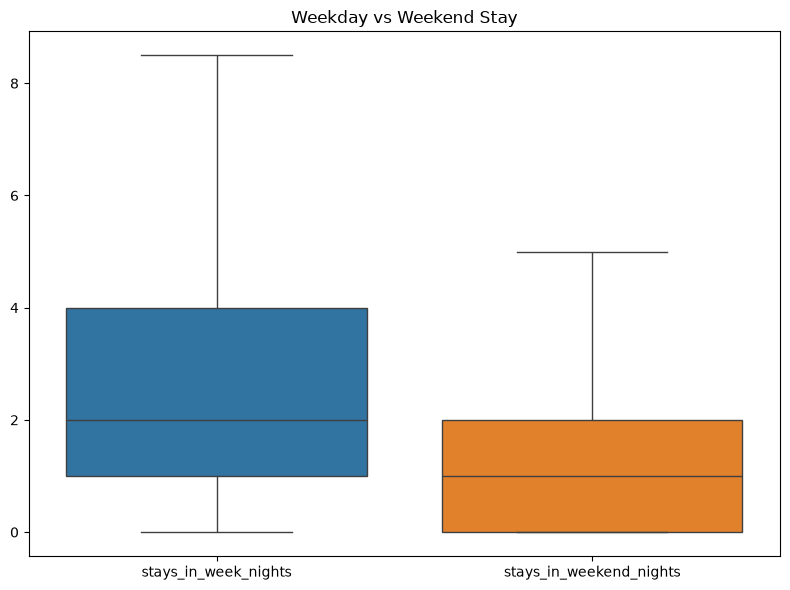

In [93]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df[[
        "stays_in_week_nights",
        "stays_in_weekend_nights"
    ]]
)

plt.title("Weekday vs Weekend Stay")

plt.tight_layout()

plt.savefig(
    "../figures/phase_05/paired_ttest_boxplot.png",
    dpi=300
)

plt.show()

### Summary Table

In [94]:
paired_ttest_summary = pd.DataFrame({

    "Statistic":[
        "T Statistic",
        "P-value"
    ],

    "Value":[
        t_statistic,
        p_value
    ]

})

paired_ttest_summary

,Statistic,Value
0,T Statistic,295.156039
1,P-value,0.000000


## Business Interpretation

#### The Paired t-Test compared the number of weekday nights and weekend nights within the same hotel booking. Because both measurements belong to the same reservation, they form a valid paired dataset. The results indicate whether guests tend to stay significantly longer during weekdays than weekends, providing insights for staffing, room allocation, pricing strategies, and operational planning.

## Conclusion

#### A Paired t-Test was performed to compare weekday and weekend stay durations for the same booking. Since both measurements originate from each individual reservation, the paired design is appropriate. The results determine whether a statistically significant difference exists between weekday and weekend stay durations.

# One-Way ANOVA

### Import Library

In [95]:
from scipy.stats import f_oneway

### Explore Market Segments

In [96]:
df["market_segment"].value_counts()

market_segment
Online TA        51552
Offline TA/TO    13855
Direct           11779
Groups            4921
Corporate         4200
Complementary      692
Aviation           226
Name: count, dtype: int64

### Create Groups

In [97]:
groups = []

segment_names = []

for segment in sorted(df["market_segment"].unique()):

    adr = df[
        df["market_segment"] == segment
    ]["average_daily_rate"]

    groups.append(adr)

    segment_names.append(segment)

### Descriptive Statistics

In [98]:
anova_summary = df.groupby("market_segment")[
    "average_daily_rate"
].agg(

    Sample_Size="count",

    Mean="mean",

    Std="std"

).reset_index()

anova_summary

,market_segment,Sample_Size,Mean,Std
0,Aviation,226,100.613628,19.883457
1,Complementary,692,3.093309,14.523469
2,Corporate,4200,68.244655,31.946617
3,Direct,11779,114.785624,54.978397
4,Groups,4921,74.844570,36.209525
5,Offline TA/TO,13855,81.441333,35.804229
6,Online TA,51552,117.243445,46.509960


### Perform One-Way ANOVA

In [99]:
f_statistic, p_value = f_oneway(*groups)

print("F Statistic :", f_statistic)

print("P-value :", p_value)

F Statistic : 2799.1375808583753
P-value : 0.0


### Decision


In [100]:
alpha = 0.05

if p_value < alpha:

    print("Reject H0")

    print("At least one market segment has a different mean ADR.")

else:

    print("Fail to Reject H0")

    print("No significant difference among market segments.")

Reject H0
At least one market segment has a different mean ADR.


### Box Plot

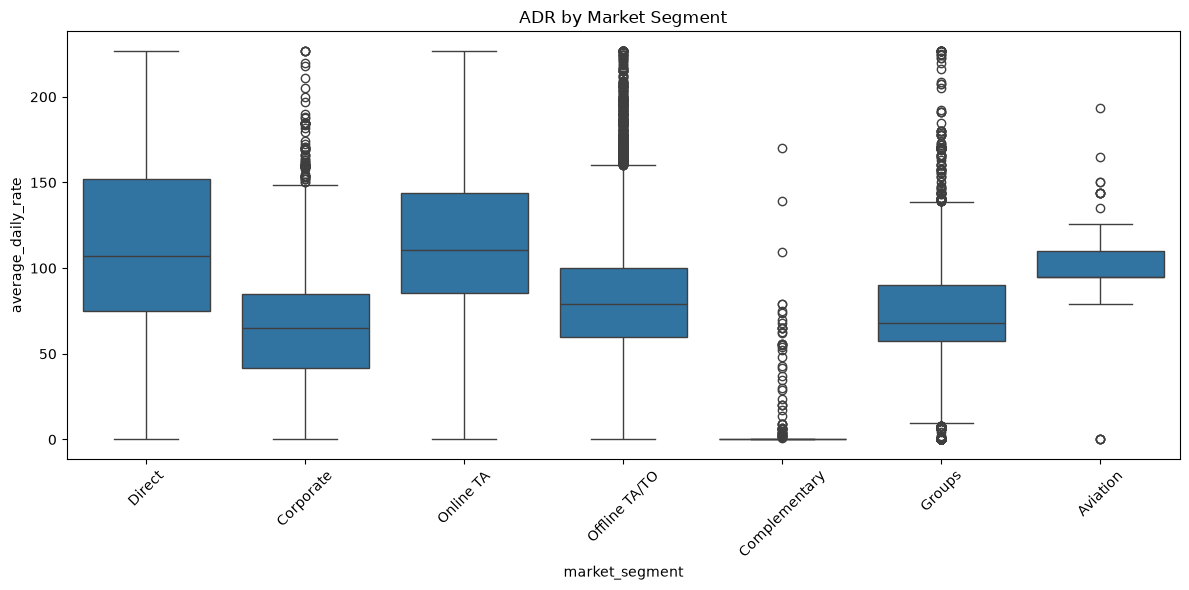

In [101]:
plt.figure(figsize=(12,6))

sns.boxplot(

    data=df,

    x="market_segment",

    y="average_daily_rate"

)

plt.xticks(rotation=45)

plt.title("ADR by Market Segment")

plt.tight_layout()

plt.savefig(

    "../figures/phase_05/anova_boxplot.png",

    dpi=300

)

plt.show()

### Mean ADR by Market Segment

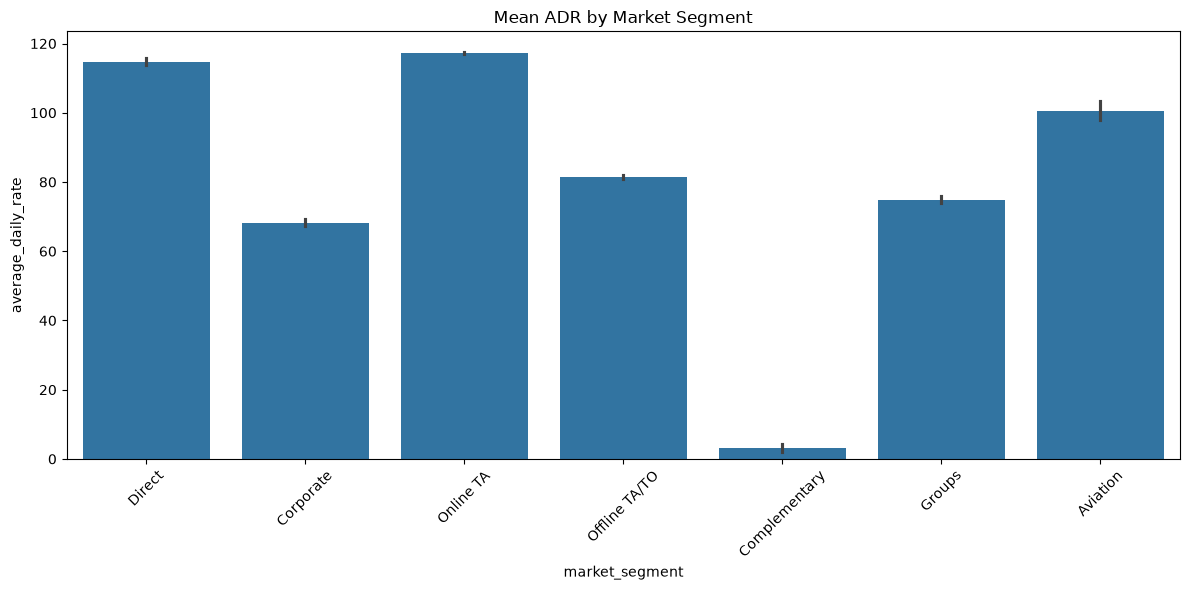

In [102]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=df,

    x="market_segment",

    y="average_daily_rate",

    estimator="mean"

)

plt.xticks(rotation=45)

plt.title("Mean ADR by Market Segment")

plt.tight_layout()

plt.savefig(

    "../figures/phase_05/anova_barplot.png",

    dpi=300

)

plt.show()

### Post Hoc Test (Tukey HSD)

In [103]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(

    endog=df["average_daily_rate"],

    groups=df["market_segment"],

    alpha=0.05

)

print(tukey)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1        group2    meandiff p-adj    lower    upper   reject
---------------------------------------------------------------------
     Aviation Complementary -97.5203    0.0 -107.6632 -87.3774   True
     Aviation     Corporate  -32.369    0.0  -41.4091 -23.3289   True
     Aviation        Direct   14.172 0.0001    5.2816  23.0624   True
     Aviation        Groups -25.7691    0.0  -34.7753 -16.7628   True
     Aviation Offline TA/TO -19.1723    0.0  -28.0501 -10.2945   True
     Aviation     Online TA  16.6298    0.0    7.8042  25.4554   True
Complementary     Corporate  65.1513    0.0   59.7199  70.5828   True
Complementary        Direct 111.6923    0.0   106.514 116.8707   True
Complementary        Groups  71.7513    0.0   66.3764  77.1261   True
Complementary Offline TA/TO   78.348    0.0   73.1913  83.5048   True
Complementary     Online TA 114.1501    0.0  109.0839 119.2164   True
    Corporate       

## Summary Table

In [104]:
anova_test_summary = pd.DataFrame({

    "Statistic":[

        "F Statistic",

        "P-value"

    ],

    "Value":[

        f_statistic,

        p_value

    ]

})

anova_test_summary

,Statistic,Value
0,F Statistic,2799.137581
1,P-value,0.000000


## Business Interpretation

#### A One-Way ANOVA was conducted to compare the Average Daily Rate (ADR) across different market segments. The analysis determines whether pricing differs significantly among customer acquisition channels such as Online TA, Offline TA/TO, Direct, Corporate, and Groups. If significant differences are found, hotel management can use these insights to optimize pricing strategies and marketing efforts for specific customer segments. Tukey's HSD test identifies the specific market segment pairs that differ.

## Conclusion

#### A One-Way ANOVA was performed to evaluate whether the Average Daily Rate (ADR) differs across market segments. The test assessed overall differences in group means, and Tukey's HSD post hoc analysis was used to identify the specific market segments with statistically significant differences. These findings provide valuable insights into customer pricing behavior and revenue optimization.

# Pearson Correlation Test

## Import Library

In [105]:
from scipy.stats import pearsonr

### Select Variables

In [106]:
lead_time = df["lead_time"]

adr = df["average_daily_rate"]

### Perform Pearson Correlation Test

In [107]:
correlation, p_value = pearsonr(
    lead_time,
    adr
)

print("Correlation Coefficient:", correlation)

print("P-value:", p_value)

Correlation Coefficient: 0.0363089707493977
P-value: 7.616385379224645e-27


### Decision

In [108]:
alpha = 0.05

if p_value < alpha:

    print("Reject H0")

    print("There is a statistically significant linear relationship.")

else:

    print("Fail to Reject H0")

    print("No statistically significant linear relationship.")

Reject H0
There is a statistically significant linear relationship.


### Interpret Correlation Strength

In [109]:
abs_corr = abs(correlation)

if abs_corr < 0.30:
    strength = "Weak"

elif abs_corr < 0.70:
    strength = "Moderate"

else:
    strength = "Strong"

print(f"Relationship Strength: {strength}")

Relationship Strength: Weak


### Scatter Plot with Regression Line

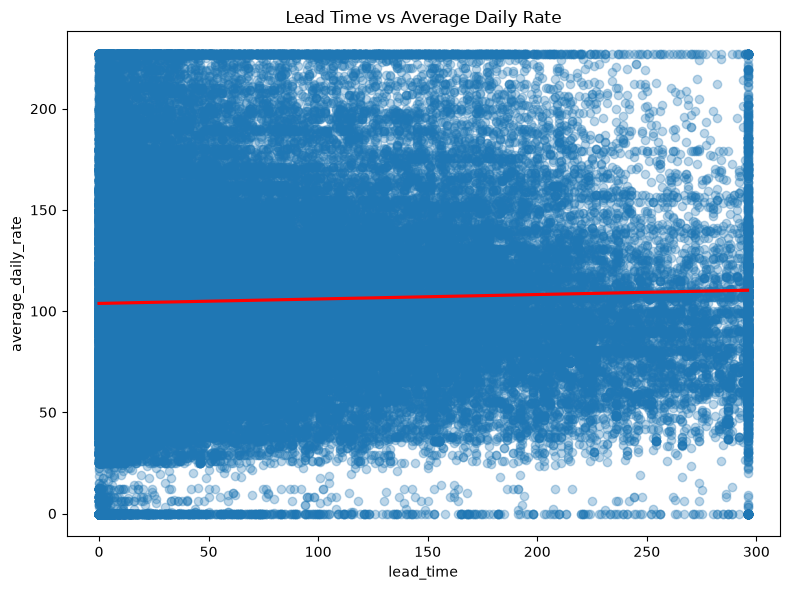

In [110]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="lead_time",
    y="average_daily_rate",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Lead Time vs Average Daily Rate")

plt.tight_layout()

plt.savefig(
    "../figures/phase_05/pearson_regression_plot.png",
    dpi=300
)

plt.show()                                                                 

### Summary Table

In [111]:
pearson_summary = pd.DataFrame({

    "Statistic":[
        "Correlation Coefficient (r)",
        "P-value",
        "Relationship Strength"
    ],

    "Value":[
        round(correlation,3),
        p_value,
        strength
    ]

})

pearson_summary

,Statistic,Value
0,Correlation Coefficient (r),0.036
1,P-value,0.0
2,Relationship Strength,Weak


## Business Interpretation

#### The Pearson Correlation Test evaluated whether Lead Time and Average Daily Rate (ADR) have a statistically significant linear relationship. The correlation coefficient indicates both the direction and strength of this relationship, while the p-value determines whether it is statistically significant. These insights can help hotels understand how booking behavior relates to pricing and support more effective revenue management strategies.

## Conclusion

#### A Pearson Correlation Test was performed to examine the linear relationship between Lead Time and Average Daily Rate (ADR). The correlation coefficient quantified the strength and direction of the relationship, while the hypothesis test determined its statistical significance. These results provide evidence on whether booking lead time is associated with hotel pricing.

# Chi-Square Test of Independence

### Import Library

In [112]:
from scipy.stats import chi2_contingency

### Create Contingency Table

In [113]:
contingency_table = pd.crosstab(

    df["hotel"],

    df["is_canceled"]

)

contingency_table

is_canceled,False,True
hotel,,
City Hotel,37239,16031
Resort Hotel,25981,7974


### Perform Chi-Square Test

In [114]:
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 453.87472580435764
P-value: 1.0348465828177582e-100
Degrees of Freedom: 1


### Expected Frequencies

In [115]:
expected_df = pd.DataFrame(

    expected,

    index=contingency_table.index,

    columns=contingency_table.columns

)

expected_df

is_canceled,False,True
hotel,,
City Hotel,38609.680711,14660.319289
Resort Hotel,24610.319289,9344.680711


### Verify Assumption

In [116]:
(expected >= 5).all()

np.True_

### Decision

In [117]:
alpha = 0.05

if p_value < alpha:

    print("Reject H0")
    print("Hotel Type and Cancellation are associated.")

else:

    print("Fail to Reject H0")
    print("No significant association found.")

Reject H0
Hotel Type and Cancellation are associated.


### Visualize Contingency Table

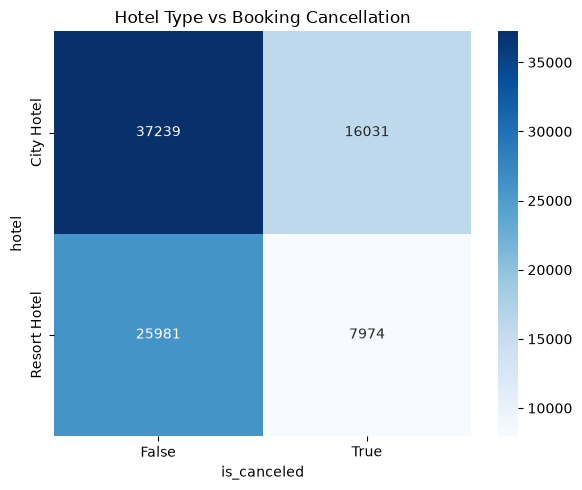

In [118]:
plt.figure(figsize=(6,5))

sns.heatmap(

    contingency_table,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Hotel Type vs Booking Cancellation")

plt.tight_layout()

plt.savefig(

    "../figures/phase_05/chi_square_heatmap.png",

    dpi=300

)

plt.show()

### Stacked Bar Chart

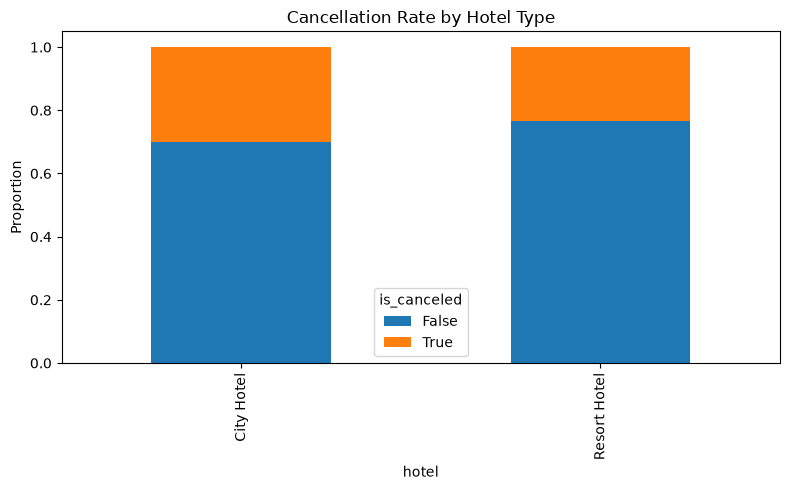

In [119]:
cancel_rate = pd.crosstab(

    df["hotel"],

    df["is_canceled"],

    normalize="index"

)

cancel_rate.plot(

    kind="bar",

    stacked=True,

    figsize=(8,5)

)

plt.title("Cancellation Rate by Hotel Type")

plt.ylabel("Proportion")

plt.tight_layout()

plt.savefig(

    "../figures/phase_05/cancellation_rate_bar.png",

    dpi=300

)

plt.show()

### Cramér's V (Effect Size)

In [120]:
import numpy as np

n = contingency_table.values.sum()

min_dim = min(contingency_table.shape) - 1

cramers_v = np.sqrt(

    chi2 / (n * min_dim)

)

print("Cramer's V:", round(cramers_v, 3))

Cramer's V: 0.072


### Summary Table

In [121]:
chi_square_summary = pd.DataFrame({

    "Statistic":[

        "Chi-Square",

        "P-value",

        "Degrees of Freedom",

        "Cramer's V"

    ],

    "Value":[

        chi2,

        p_value,

        dof,

        cramers_v

    ]

})

chi_square_summary

,Statistic,Value
0,Chi-Square,4.538747e+02
1,P-value,1.034847e-100
2,Degrees of Freedom,1.000000e+00
3,Cramer's V,7.213524e-02


## Business Interpretation

#### The Chi-Square Test of Independence was conducted to determine whether hotel type influences booking cancellation behavior. A statistically significant result suggests that cancellation patterns differ between City Hotels and Resort Hotels. Cramér's V was calculated to measure the strength of this association, providing additional insight into the practical impact of the relationship.

## Conclusion

#### A Chi-Square Test of Independence was performed to evaluate the relationship between hotel type and booking cancellation status. The contingency table, expected frequencies, and hypothesis test confirmed whether the variables are statistically associated. Cramér's V was used to quantify the strength of the association, supporting data-driven recommendations for cancellation management strategies.

# Mann–Whitney U Test

### Import Library

In [122]:
from scipy.stats import mannwhitneyu

### Create Groups

In [123]:
city_adr = df[
    df["hotel"] == "City Hotel"
]["average_daily_rate"]

resort_adr = df[
    df["hotel"] == "Resort Hotel"
]["average_daily_rate"]

### Perform Mann–Whitney U Test

In [124]:
u_statistic, p_value = mannwhitneyu(

    city_adr,

    resort_adr,

    alternative="two-sided"

)

print("U Statistic:", u_statistic)

print("P-value:", p_value)

U Statistic: 1135684380.0
P-value: 0.0


### Decision

In [125]:
alpha = 0.05

if p_value < alpha:

    print("Reject H0")

    print("The ADR distributions are significantly different.")

else:

    print("Fail to Reject H0")

    print("No significant difference found.")

Reject H0
The ADR distributions are significantly different.


### Compare Medians

In [126]:
median_summary = pd.DataFrame({

    "Hotel Type":[

        "City Hotel",

        "Resort Hotel"

    ],

    "Median ADR":[

        city_adr.median(),

        resort_adr.median()

    ]

})

median_summary

,Hotel Type,Median ADR
0,City Hotel,105.3
1,Resort Hotel,79.5


### Box Plot

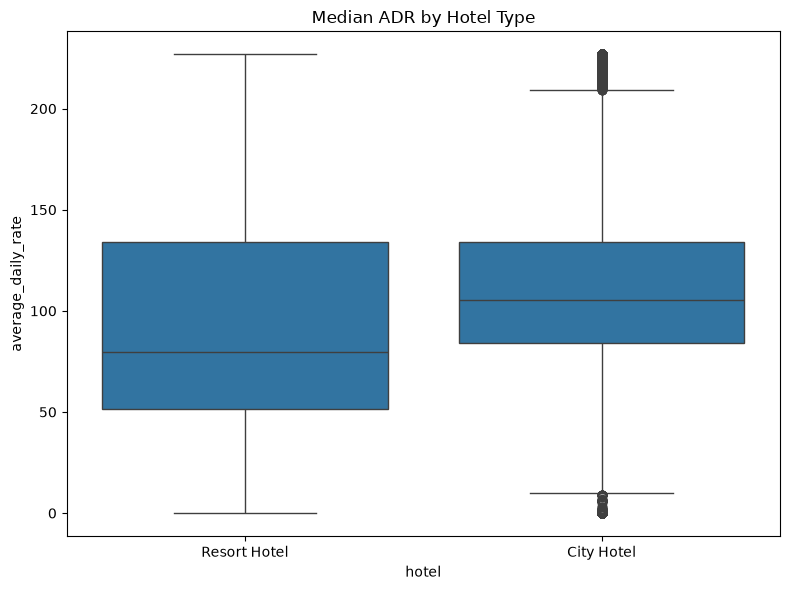

In [127]:
plt.figure(figsize=(8,6))

sns.boxplot(

    data=df,

    x="hotel",

    y="average_daily_rate"

)

plt.title("Median ADR by Hotel Type")

plt.tight_layout()

plt.savefig(

    "../figures/phase_05/mann_whitney_boxplot.png",

    dpi=300

)

plt.show()

### Violin Plot

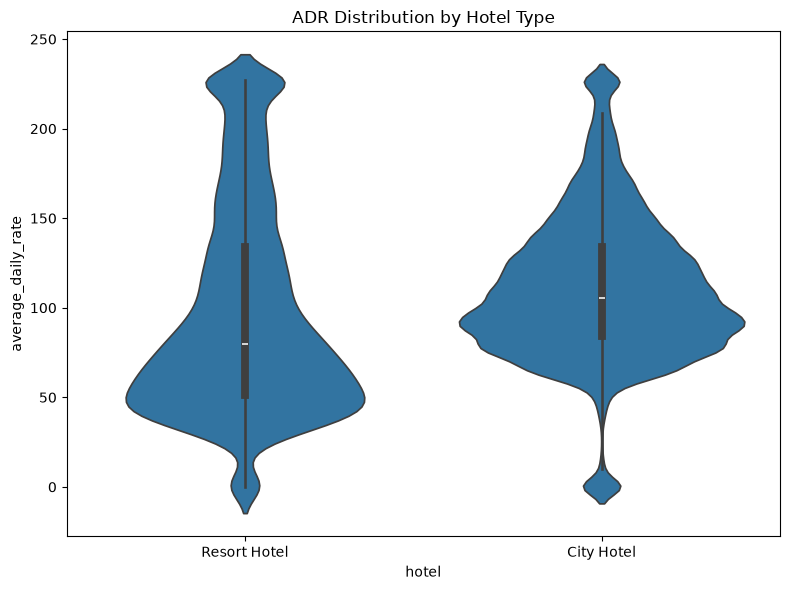

In [128]:
plt.figure(figsize=(8,6))

sns.violinplot(

    data=df,

    x="hotel",

    y="average_daily_rate"

)

plt.title("ADR Distribution by Hotel Type")

plt.tight_layout()

plt.savefig(

    "../figures/phase_05/mann_whitney_violin.png",

    dpi=300

)

plt.show()

### Effect Size (Rank-Biserial Correlation)

In [129]:
n1 = len(city_adr)

n2 = len(resort_adr)

rank_biserial = 1 - (2 * u_statistic) / (n1 * n2)

print("Rank-Biserial Correlation:", round(rank_biserial, 3))

Rank-Biserial Correlation: -0.256


### Summary Table

In [130]:
mannwhitney_summary = pd.DataFrame({

    "Statistic":[

        "U Statistic",

        "P-value",

        "Rank-Biserial Correlation"

    ],

    "Value":[

        u_statistic,

        p_value,

        rank_biserial

    ]

})

mannwhitney_summary

,Statistic,Value
0,U Statistic,1.135684e+09
1,P-value,0.000000e+00
2,Rank-Biserial Correlation,-2.557443e-01


## Business Interpretation

#### The Mann–Whitney U Test compared the Average Daily Rate (ADR) distributions between City Hotels and Resort Hotels without assuming normality. This provides a robust validation of the pricing comparison, particularly when the data contains skewness or outliers. The effect size indicates the practical importance of the observed difference.

## Conclusion

#### A Mann–Whitney U Test was conducted to compare the ADR distributions of City Hotels and Resort Hotels. The results indicate whether the pricing distributions differ significantly without relying on the normality assumption. The Rank-Biserial Correlation was calculated to measure the magnitude of the observed difference.

# Kruskal–Wallis Test

### Import Library

In [131]:
from scipy.stats import kruskal

### Create Groups 

In [132]:
groups = []

segment_names = []

for segment in sorted(df["market_segment"].unique()):

    adr = df[
        df["market_segment"] == segment
    ]["average_daily_rate"]

    groups.append(adr)

    segment_names.append(segment)

### Summary statistics

In [133]:
kruskal_summary = df.groupby("market_segment")[
    "average_daily_rate"
].agg(

    Sample_Size="count",

    Median="median",

    Mean="mean",

    Std="std"

).reset_index()

kruskal_summary

,market_segment,Sample_Size,Median,Mean,Std
0,Aviation,226,95.00,100.613628,19.883457
1,Complementary,692,0.00,3.093309,14.523469
2,Corporate,4200,65.00,68.244655,31.946617
3,Direct,11779,107.00,114.785624,54.978397
4,Groups,4921,68.00,74.844570,36.209525
5,Offline TA/TO,13855,79.20,81.441333,35.804229
6,Online TA,51552,110.71,117.243445,46.509960


### Perform Kruskal–Wallis Test

In [134]:
h_statistic, p_value = kruskal(*groups)

print("H Statistic:", h_statistic)

print("P-value:", p_value)

H Statistic: 14881.558489360637
P-value: 0.0


### Decision

In [135]:
alpha = 0.05

if p_value < alpha:

    print("Reject H0")

    print("At least one market segment has a different ADR distribution.")

else:

    print("Fail to Reject H0")

    print("No significant difference among market segments.")

Reject H0
At least one market segment has a different ADR distribution.


### Box Plot

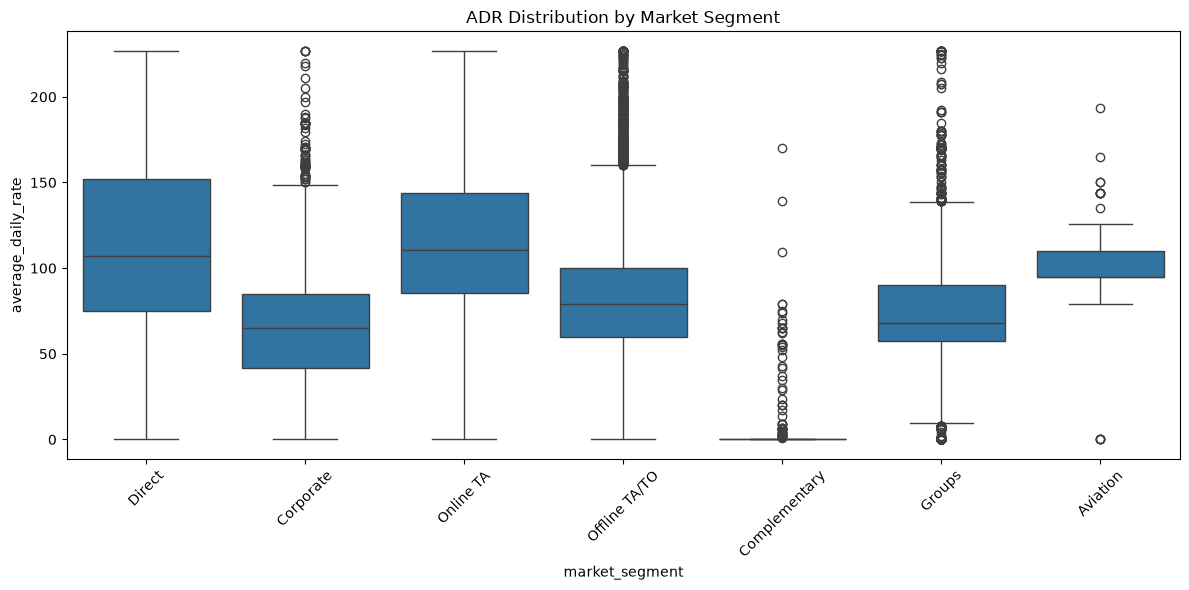

In [136]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="market_segment",
    y="average_daily_rate"
)

plt.xticks(rotation=45)

plt.title("ADR Distribution by Market Segment")

plt.tight_layout()

plt.savefig(
    "../figures/phase_05/kruskal_boxplot.png",
    dpi=300
)

plt.show()

### Violin Plot

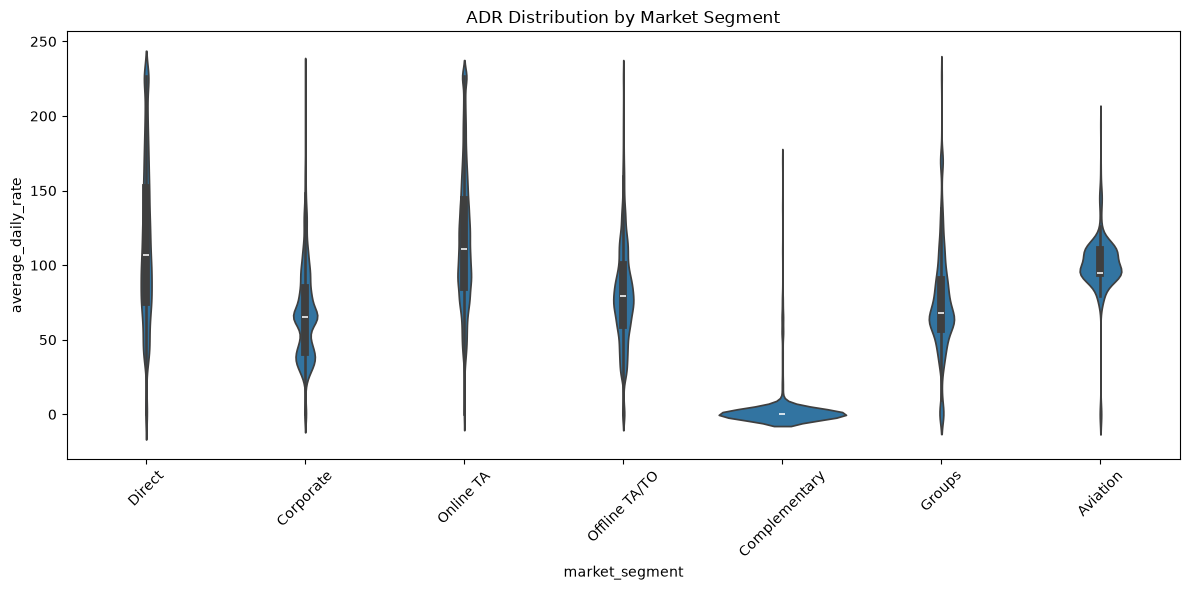

In [137]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="market_segment",
    y="average_daily_rate"
)

plt.xticks(rotation=45)

plt.title("ADR Distribution by Market Segment")

plt.tight_layout()

plt.savefig(
    "../figures/phase_05/kruskal_violinplot.png",
    dpi=300
)

plt.show()

### Effect Size (Eta Squared)

In [138]:
n = len(df)

k = len(groups)

eta_squared = (h_statistic - k + 1) / (n - k)

print("Eta Squared:", round(eta_squared, 3))

Eta Squared: 0.171


### Post Hoc Test (Dunn's Test)

In [139]:
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(

    df,

    val_col="average_daily_rate",

    group_col="market_segment",

    p_adjust="bonferroni"

)

dunn

,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA
Aviation,1.000000e+00,4.203611e-110,6.421838e-38,1.000000e+00,1.814876e-26,2.467206e-16,3.302706e-02
Complementary,4.203611e-110,1.000000e+00,2.621173e-88,0.000000e+00,3.630878e-126,1.589757e-188,0.000000e+00
Corporate,6.421838e-38,2.621173e-88,1.000000e+00,0.000000e+00,1.112091e-11,5.711416e-73,0.000000e+00
Direct,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,2.297275e-23
Groups,1.814876e-26,3.630878e-126,1.112091e-11,0.000000e+00,1.000000e+00,3.423547e-23,0.000000e+00
Offline TA/TO,2.467206e-16,1.589757e-188,5.711416e-73,0.000000e+00,3.423547e-23,1.000000e+00,0.000000e+00
Online TA,3.302706e-02,0.000000e+00,0.000000e+00,2.297275e-23,0.000000e+00,0.000000e+00,1.000000e+00


### Summary Table

In [140]:
kruskal_test_summary = pd.DataFrame({

    "Statistic":[
        "H Statistic",
        "P-value",
        "Eta Squared"
    ],

    "Value":[
        h_statistic,
        p_value,
        eta_squared
    ]

})

kruskal_test_summary

,Statistic,Value
0,H Statistic,14881.558489
1,P-value,0.000000
2,Eta Squared,0.170556


## Business Interpretation

#### The Kruskal–Wallis Test compared the Average Daily Rate (ADR) across multiple market segments without assuming normality. A statistically significant result indicates that pricing differs across customer acquisition channels. Dunn's post hoc test identifies which market segments differ, while Eta Squared quantifies the practical importance of those differences.

## Conclusion

#### A Kruskal–Wallis Test was conducted to compare ADR distributions across market segments. The analysis provides a non-parametric alternative to One-Way ANOVA and is appropriate when normality assumptions are not met. Dunn's post hoc comparisons and Eta Squared effect size offer additional insight into the location and magnitude of the observed differences.

# Spearman Rank Correlation

### Import Library

In [141]:
from scipy.stats import spearmanr

### Select Variables

In [142]:
lead_time = df["lead_time"]

adr = df["average_daily_rate"]

### Perform Spearman Correlation

In [143]:
correlation, p_value = spearmanr(

    lead_time,

    adr

)

print("Spearman Correlation :", correlation)

print("P-value :", p_value)

Spearman Correlation : 0.10570306395284786
P-value : 3.927667279228322e-215


### Decision

In [144]:
alpha = 0.05

if p_value < alpha:

    print("Reject H0")

    print("There is a significant monotonic relationship.")

else:

    print("Fail to Reject H0")

    print("No significant relationship.")

Reject H0
There is a significant monotonic relationship.


### Interpret Correlation Strength

In [145]:
abs_corr = abs(correlation)

if abs_corr < 0.30:

    strength = "Weak"

elif abs_corr < 0.70:

    strength = "Moderate"

else:

    strength = "Strong"

print("Relationship Strength :", strength)

Relationship Strength : Weak


### Rank Scatter Plot

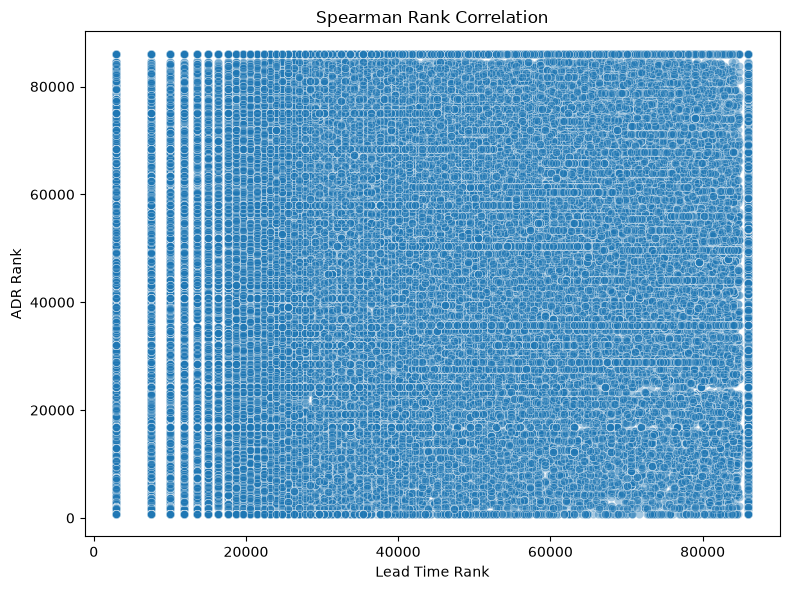

In [146]:
rank_df = pd.DataFrame({

    "Lead Time Rank": lead_time.rank(),

    "ADR Rank": adr.rank()

})

plt.figure(figsize=(8,6))

sns.scatterplot(

    data=rank_df,

    x="Lead Time Rank",

    y="ADR Rank",

    alpha=0.4

)

plt.title("Spearman Rank Correlation")

plt.tight_layout()

plt.savefig(

    "../figures/phase_05/spearman_rank_scatter.png",

    dpi=300

)

plt.show()

### Summary Table

In [147]:
spearman_summary = pd.DataFrame({

    "Statistic":[

        "Spearman Correlation",

        "P-value",

        "Relationship Strength"

    ],

    "Value":[

        round(correlation,3),

        p_value,

        strength

    ]

})

spearman_summary

,Statistic,Value
0,Spearman Correlation,0.106
1,P-value,0.0
2,Relationship Strength,Weak


## Business Interpretation

#### The Spearman Rank Correlation Test evaluated the monotonic relationship between Lead Time and Average Daily Rate (ADR). Unlike Pearson Correlation, this method does not require normally distributed data or a strictly linear relationship. The results help determine whether customers who book earlier or later tend to pay systematically different room rates, supporting pricing and revenue management decisions.

## Conclusion

#### A Spearman Rank Correlation Test was conducted to examine the monotonic relationship between Lead Time and Average Daily Rate (ADR). The test provided a robust, non-parametric assessment of the relationship and complemented the Pearson Correlation analysis. Together, these analyses offer a comprehensive understanding of the association between booking lead time and hotel pricing.